In [1]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

In [4]:
df=pd.read_csv('dataset/data_science_job.csv')
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [7]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index     479
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
training_hours             766
target                       0
dtype: int64

In [12]:
data=df.drop(columns=['enrollee_id','city','gender','relevent_experience','enrolled_university','education_level','major_discipline','company_size','company_type'],axis=1)

In [13]:
data

,city_development_index,experience,training_hours,target
0,0.920,20.0,36.0,1.0
1,0.776,15.0,47.0,0.0
2,0.624,5.0,83.0,0.0
3,0.789,0.0,52.0,1.0
4,0.767,20.0,8.0,0.0
...,...,...,...,...
19153,0.878,14.0,42.0,1.0
19154,0.920,14.0,52.0,1.0
19155,0.920,20.0,44.0,0.0
19156,0.802,0.0,97.0,0.0


In [14]:
data.isnull().sum()

city_development_index    479
experience                 65
training_hours            766
target                      0
dtype: int64

In [17]:
data.isnull().mean()*100

city_development_index    2.500261
experience                0.339284
training_hours            3.998330
target                    0.000000
dtype: float64

In [18]:
data['target'].value_counts()

target
0.0    14381
1.0     4777
Name: count, dtype: int64

In [19]:
x=data.iloc[:,0:3]
y=data.iloc[:,-1]

In [23]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [25]:
X_train.isnull().mean()

city_development_index    0.024664
experience                0.003132
training_hours            0.038431
dtype: float64

In [26]:
data.head()

,city_development_index,experience,training_hours,target
0,0.920,20.0,36.0,1.0
1,0.776,15.0,47.0,0.0
2,0.624,5.0,83.0,0.0
3,0.789,0.0,52.0,1.0
4,0.767,20.0,8.0,0.0


# Filling Mean and Median

In [27]:
mean_city_development_index=X_train['city_development_index'].mean()
median_city_development_index=X_train['city_development_index'].median()

mean_experience=X_train['experience'].mean()
median_experience=X_train['experience'].median()

mean_training_hours=X_train['training_hours'].mean()
median_training_hours=X_train['training_hours'].median()

In [29]:
X_train['City_idx_dev_mean']=X_train['city_development_index'].fillna(mean_city_development_index)
X_train['City_idx_dev_median']=X_train['city_development_index'].fillna(median_city_development_index)

X_train['Experience_mean']=X_train['experience'].fillna(mean_experience)
X_train['Experience_median']=X_train['experience'].fillna(median_experience)

X_train['Training_hours_mean']=X_train['training_hours'].fillna(mean_training_hours)
X_train['Training_hours_median']=X_train['training_hours'].fillna(median_training_hours)

In [31]:
X_train.sample(10)

,city_development_index,experience,training_hours,City_idx_dev_mean,City_idx_dev_median,Experience_mean,Experience_median,Training_hours_mean,Training_hours_median
212,0.624,3.0,42.0,0.624,0.624,3.0,3.0,42.0,42.0
14895,0.743,7.0,18.0,0.743,0.743,7.0,7.0,18.0,18.0
13601,0.910,20.0,182.0,0.910,0.910,20.0,20.0,182.0,182.0
15629,0.926,16.0,110.0,0.926,0.926,16.0,16.0,110.0,110.0
7642,0.897,11.0,88.0,0.897,0.897,11.0,11.0,88.0,88.0
18751,0.624,6.0,155.0,0.624,0.624,6.0,6.0,155.0,155.0
12287,0.920,5.0,15.0,0.920,0.920,5.0,5.0,15.0,15.0
11778,0.926,3.0,22.0,0.926,0.926,3.0,3.0,22.0,22.0
12647,0.762,9.0,67.0,0.762,0.762,9.0,9.0,67.0,67.0
9196,0.558,4.0,46.0,0.558,0.558,4.0,4.0,46.0,46.0


In [36]:
print("Original City idx dev  variable variance: ",X_train['city_development_index'].var())
print("City idx dev after median imputaion : ",X_train['City_idx_dev_median'].var())
print("City idx dev after mean imputaion : ",X_train['City_idx_dev_mean'].var())

print("Original Experiance  : ",X_train['experience'].var())
print("Experience after mean imputation  : ",X_train['Experience_mean'].var())
print("Experiance after median impution : ",X_train['Experience_median'].var())

print("Original training_hours: ",X_train['training_hours'].var())
print("Training hours  mean after the  imputation : ",X_train['Training_hours_mean'].var())
print("Training hours after median the imputation : ",X_train['Training_hours_median'].var())

Original City idx dev  variable variance:  0.015155109127335312
City idx dev after median imputaion :  0.01491213814350364
City idx dev after mean imputaion :  0.014781299584097336
Original Experiance  :  42.14794512091847
Experience after mean imputation  :  42.0159319812249
Experiance after median impution :  42.0187591696655
Original training_hours:  3583.246418299249
Training hours  mean after the  imputation :  3445.528170966261
Training hours after median the imputation :  3457.752387517494


# Visual 

In [ ]:
# for city index development

In [37]:
import matplotlib.pyplot as plt

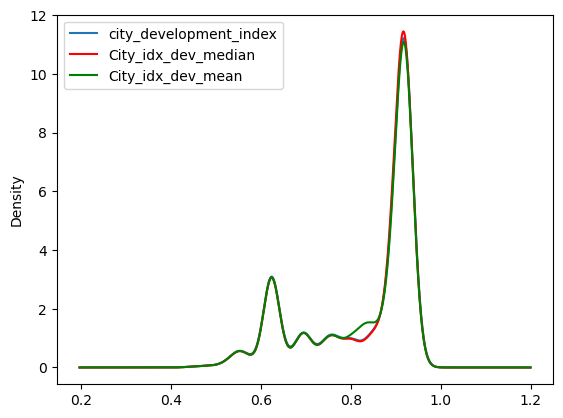

In [41]:
fig=plt.figure()
ax=fig.add_subplot(111)

# original data
X_train['city_development_index'].plot(kind='kde',ax=ax)

# meadina imputaion after
X_train['City_idx_dev_median'].plot(kind='kde',ax=ax,color='red')

# mean after imputaion
X_train['City_idx_dev_mean'].plot(kind='kde',ax=ax,color='green')

# add legend 
lines,labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

In [42]:
# for experiance

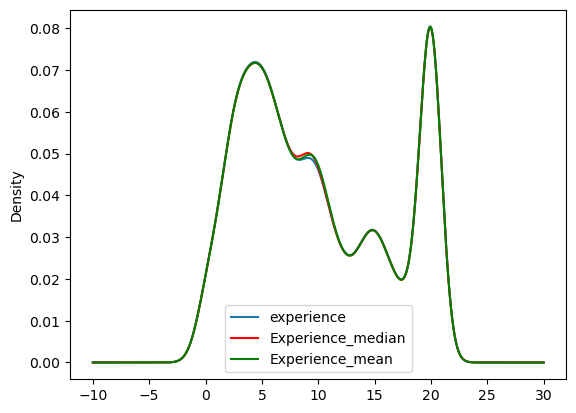

In [43]:
fig=plt.figure()
ax=fig.add_subplot(111)

# original data
X_train['experience'].plot(kind='kde',ax=ax)

# meadina imputaion after
X_train['Experience_median'].plot(kind='kde',ax=ax,color='red')

# mean after imputaion
X_train['Experience_mean'].plot(kind='kde',ax=ax,color='green')

# add legend 
lines,labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

In [46]:
#For Training hour

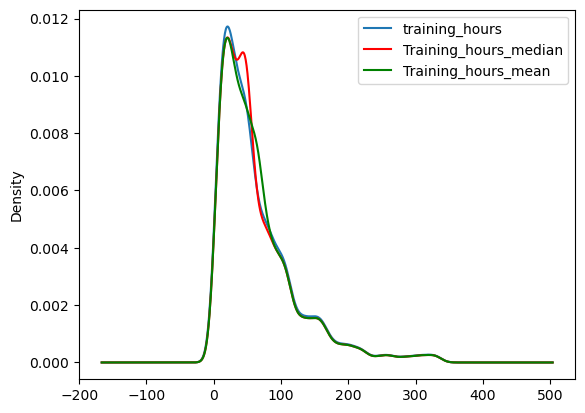

In [47]:
fig=plt.figure()
ax=fig.add_subplot(111)

# original data
X_train['training_hours'].plot(kind='kde',ax=ax)

# meadina imputaion after
X_train['Training_hours_median'].plot(kind='kde',ax=ax,color='red')

# mean after imputaion
X_train['Training_hours_mean'].plot(kind='kde',ax=ax,color='green')

# add legend 
lines,labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

# Using SimpleImputer for sklearn

In [48]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [49]:
X_train.head()

,city_development_index,experience,training_hours
13330,0.910,2.0,16.0
18074,0.897,6.0,262.0
366,0.910,3.0,24.0
10662,0.910,3.0,35.0
13974,NaN,4.0,43.0


In [50]:
imp1=SimpleImputer(strategy='median')
imp2=SimpleImputer(strategy='mean')

In [51]:
trf=ColumnTransformer([
    ('imp1',imp1,['experience']),
    ('imp2',imp2,['training_hours'])
],remainder='passthrough')

In [52]:
trf.fit(X_train)

C:\Users\91886\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imp1', SimpleImputer(strategy='median'),
                                 ['experience']),
                                ('imp2', SimpleImputer(), ['training_hours'])])

In [60]:
trf.named_transformers_['imp1'].statistics_

array([9.])

In [61]:
trf.named_transformers_['imp2'].statistics_

array([65.18708014])

In [59]:
X_train=trf.transform(X_train)
_test=trf.transform(X_test)

ValueError: Specifying the columns using strings is only supported for dataframes.

In [56]:
X_train

array([[  2.   ,  16.   ,   0.91 ],
       [  6.   , 262.   ,   0.897],
       [  3.   ,  24.   ,   0.91 ],
       ...,
       [ 10.   ,  57.   ,   0.893],
       [  5.   ,  16.   ,   0.624],
       [ 20.   ,  50.   ,   0.866]])

In [57]:
x_test

,city_development_index,experience,training_hours
16144,0.910,6.0,21.0
13661,0.920,20.0,74.0
344,0.924,9.0,94.0
1034,0.624,15.0,75.0
8109,NaN,12.0,157.0
...,...,...,...
13955,0.855,1.0,176.0
13463,0.939,5.0,NaN
18772,0.624,2.0,4.0
12809,0.550,4.0,NaN
